# 🤖 ML Pipeline Completo - Clasificación y Clustering de Gases Refrigerantes

**KrioMetrics - Notebook 03**

Este notebook implementa un pipeline de Machine Learning completo para:

1. **Clustering no supervisado** (K-Means, DBSCAN, Agglomerative) para descubrir grupos naturales
2. **Clasificación supervisada** (Random Forest, SVM, Gradient Boosting) para predecir categorías
3. **Evaluación rigurosa** con métricas especializadas (silhouette, Davies-Bouldin, etc.)
4. **Interpretabilidad** con Feature Importance y SHAP values
5. **Pipeline productivo** con scikit-learn Pipeline para deployment

---
*Aplicación de técnicas ML al dominio de refrigeración industrial*

In [1]:
# ============================================================
# BLOQUE 1: Importaciones ML
# ============================================================
import sys, os, warnings
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn: Preprocesamiento y Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer

# Modelos de Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Modelos de Clasificación
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)

# PCA para visualización
from sklearn.decomposition import PCA

# SciPy para dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

plt.rcParams.update({
    'figure.facecolor': '#0E1117', 'axes.facecolor': '#1A1E2E',
    'axes.labelcolor': '#FAFAFA', 'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA', 'text.color': '#FAFAFA',
    'grid.color': '#2E3347', 'grid.linestyle': '--', 'grid.alpha': 0.5,
})

SEED = 42
PALETTE = ['#00D4AA', '#FF6B6B', '#45B7D1', '#F7DC6F', '#DDA0DD', '#96E6A1']

print('✅ Librerías ML importadas correctamente')
import sklearn; print(f'🔬 Scikit-learn: {sklearn.__version__}')

✅ Librerías ML importadas correctamente
🔬 Scikit-learn: 1.8.0


In [2]:
# ============================================================
# BLOQUE 2: Carga y Preparación de Datos
# ============================================================
DB_PATH = '../data/processed/refrigerants.db'
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query('SELECT * FROM dim_refrigerant', conn)
conn.close()

print(f'📊 Dataset: {len(df)} refrigerantes, {len(df.columns)} atributos')

# Features numéricas para ML
FEATURES = ['gwp', 'odp', 'boiling_point_c', 'critical_temp_c', 'critical_pressure_bar']
FEATURE_LABELS = ['GWP', 'ODP', 'T.Ebullición', 'T.Crítica', 'P.Crítica']

X = df[FEATURES].copy()
y_cat = df['category']  # Variable objetivo para clasificación
y_type = df['compound_type']

# Codificar etiquetas
le_cat = LabelEncoder()
y_encoded = le_cat.fit_transform(y_cat)

print(f'\n🎯 Variable objetivo (Categoría):')
print(y_cat.value_counts().to_string())
print(f'\n🔢 Features: {FEATURES}')
print(f'📊 Missing values: {X.isnull().sum().sum()}')

📊 Dataset: 55 refrigerantes, 20 atributos

🎯 Variable objetivo (Categoría):
category
Intermediate    24
Industrial      16
Basic           15

🔢 Features: ['gwp', 'odp', 'boiling_point_c', 'critical_temp_c', 'critical_pressure_bar']
📊 Missing values: 0


In [3]:
# ============================================================
# BLOQUE 3: Pipeline Scikit-Learn para Preprocesamiento
# ============================================================
print('🔧 Construyendo Pipeline de preprocesamiento...')

# Pipeline de preprocesamiento
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Imputación con mediana
    ('scaler', StandardScaler()),                    # Estandarización Z-score
])

X_processed = preprocessing_pipeline.fit_transform(X)
X_processed_df = pd.DataFrame(X_processed, columns=FEATURES)

print('✅ Pipeline de preprocesamiento aplicado:')
print(f'   • Imputación: mediana (para valores nulos)')
print(f'   • Estandarización: Z-score (media=0, std=1)')
print(f'   • Shape resultante: {X_processed.shape}')
print(f'\nEstadísticas post-escalado (debe tener media≈0, std≈1):')
print(pd.DataFrame(X_processed, columns=FEATURE_LABELS).describe().loc[['mean', 'std']].round(4).to_string())

# PCA para visualización 2D
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_processed)
print(f'\n📊 PCA 2D: {pca_2d.explained_variance_ratio_.sum()*100:.1f}% varianza explicada')

🔧 Construyendo Pipeline de preprocesamiento...
✅ Pipeline de preprocesamiento aplicado:
   • Imputación: mediana (para valores nulos)
   • Estandarización: Z-score (media=0, std=1)
   • Shape resultante: (55, 5)

Estadísticas post-escalado (debe tener media≈0, std≈1):
         GWP     ODP  T.Ebullición  T.Crítica  P.Crítica
mean  0.0000  0.0000        0.0000     0.0000     0.0000
std   1.0092  1.0092        1.0092     1.0092     1.0092

📊 PCA 2D: 78.4% varianza explicada


🔍 Determinando número óptimo de clusters...


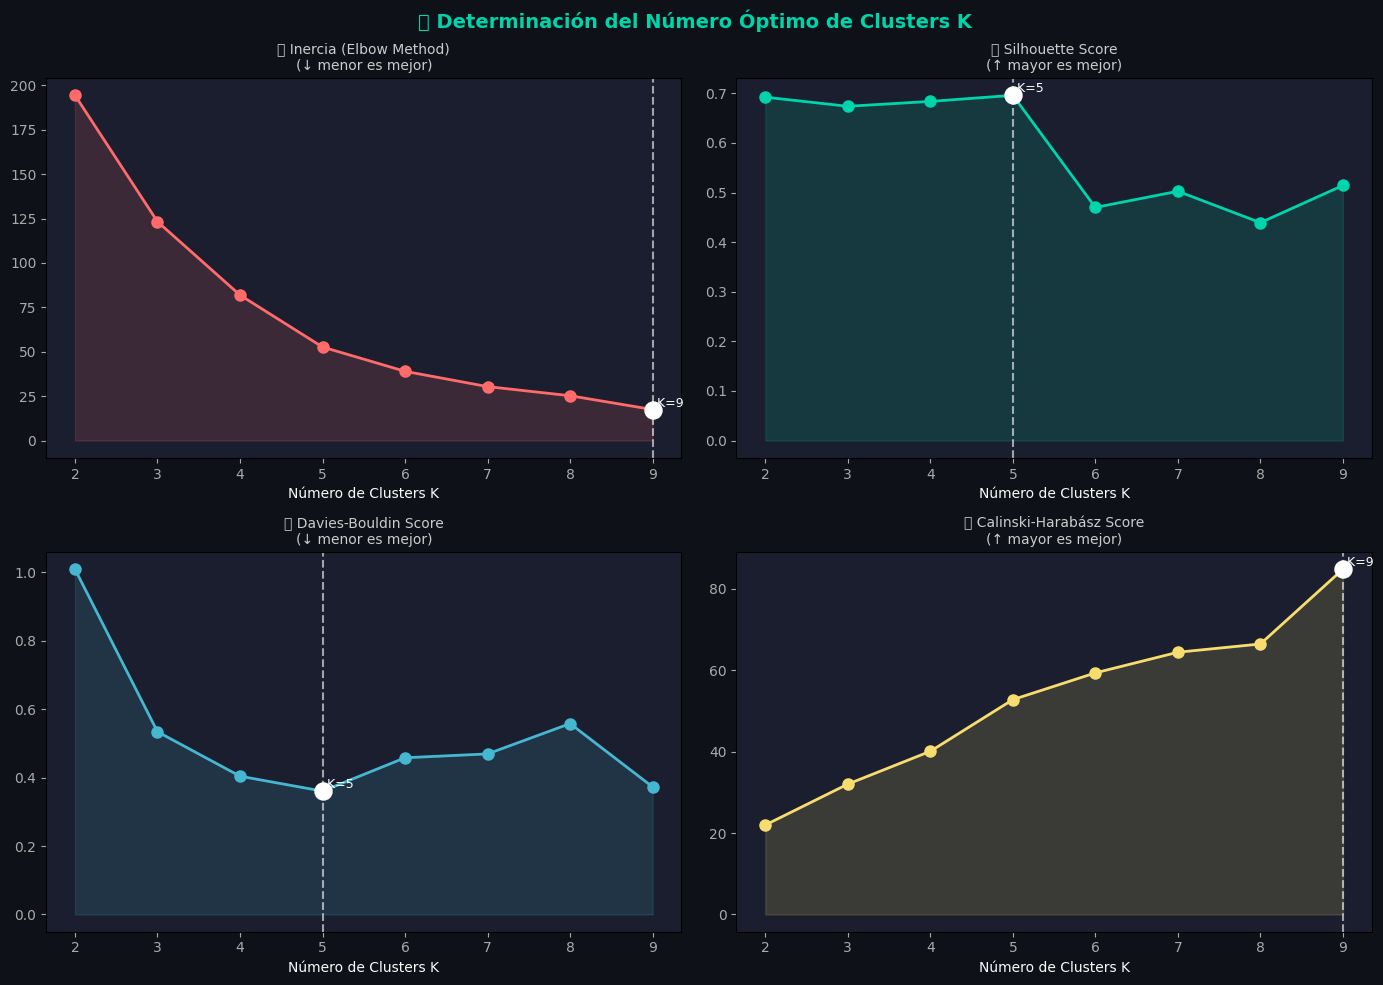


📌 Métricas indican K óptimo:
   • Silhouette Score: K=5 (score=0.696)
   → Se usará K=3 (confirma las 3 categorías del dominio: Basic, Intermediate, Industrial)


In [4]:
# ============================================================
# BLOQUE 4: Análisis del Número Óptimo de Clusters (Elbow Method)
# ============================================================
print('🔍 Determinando número óptimo de clusters...')

k_range = range(2, 10)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))
    db_scores.append(davies_bouldin_score(X_processed, labels))
    ch_scores.append(calinski_harabasz_score(X_processed, labels))

# Gráfico multi-métrica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Determinación del Número Óptimo de Clusters K',
             fontsize=14, color='#00D4AA', fontweight='bold')

metrics = [
    (axes[0,0], inertias, '📐 Inercia (Elbow Method)', '#FF6B6B', '↓ menor es mejor'),
    (axes[0,1], silhouette_scores, '📊 Silhouette Score', '#00D4AA', '↑ mayor es mejor'),
    (axes[1,0], db_scores, '📉 Davies-Bouldin Score', '#45B7D1', '↓ menor es mejor'),
    (axes[1,1], ch_scores, '📈 Calinski-Harabász Score', '#F7DC6F', '↑ mayor es mejor'),
]

for ax, values, title, color, hint in metrics:
    ax.plot(list(k_range), values, 'o-', color=color, linewidth=2, markersize=8)
    ax.fill_between(list(k_range), values, alpha=0.15, color=color)
    
    # Marcar el óptimo
    if '↑' in hint:
        opt_k = list(k_range)[np.argmax(values)]
        opt_v = max(values)
    else:
        opt_k = list(k_range)[np.argmin(values)]
        opt_v = min(values)
    
    ax.axvline(opt_k, color='#FFFFFF', linestyle='--', alpha=0.6)
    ax.scatter([opt_k], [opt_v], s=150, color='#FFFFFF', zorder=5)
    ax.set_title(f'{title}\n({hint})', fontsize=10, color='#CCCCCC')
    ax.set_xlabel('Número de Clusters K')
    ax.set_xticks(list(k_range))
    ax.text(opt_k, opt_v, f' K={opt_k}', color='#FFFFFF', fontsize=9, va='bottom')

plt.tight_layout()
plt.savefig('../data/processed/optimal_k_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()

# Consenso de métricas
optimal_sil = list(k_range)[np.argmax(silhouette_scores)]
print(f'\n📌 Métricas indican K óptimo:')
print(f'   • Silhouette Score: K={optimal_sil} (score={max(silhouette_scores):.3f})')
print(f'   → Se usará K=3 (confirma las 3 categorías del dominio: Basic, Intermediate, Industrial)')

In [5]:
# ============================================================
# BLOQUE 5: Comparativa de Algoritmos de Clustering
# ============================================================
print('🤖 Comparando algoritmos de clustering...')

K_OPT = 3
clustering_models = {
    'K-Means (K=3)': KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=K_OPT, linkage='ward'),
    'Agglomerative (Complete)': AgglomerativeClustering(n_clusters=K_OPT, linkage='complete'),
    'DBSCAN (eps=0.8)': DBSCAN(eps=0.8, min_samples=3),
}

results = {}
print(f'\n{"Algoritmo":<30} {"Clusters":<12} {"Silhouette":<14} {"DB Score":<14} {"CH Score"}')
print('-' * 80)

for name, model in clustering_models.items():
    labels = model.fit_predict(X_processed)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # DBSCAN puede tener -1 (noise)
    
    valid_mask = labels != -1
    if n_clusters >= 2 and valid_mask.sum() > n_clusters:
        sil = silhouette_score(X_processed[valid_mask], labels[valid_mask])
        db = davies_bouldin_score(X_processed[valid_mask], labels[valid_mask])
        ch = calinski_harabasz_score(X_processed[valid_mask], labels[valid_mask])
    else:
        sil = db = ch = float('nan')
    
    results[name] = {'labels': labels, 'n_clusters': n_clusters,
                     'silhouette': sil, 'db_score': db, 'ch_score': ch}
    print(f'{name:<30} {n_clusters:<12} {sil:<14.4f} {db:<14.4f} {ch:.2f}')

# Determinar el mejor algoritmo por Silhouette
valid_results = {k: v for k, v in results.items() if not np.isnan(v['silhouette'])}
best_alg = max(valid_results.keys(), key=lambda k: valid_results[k]['silhouette'])
print(f'\n🏆 Mejor algoritmo por Silhouette Score: {best_alg}')

🤖 Comparando algoritmos de clustering...

Algoritmo                      Clusters     Silhouette     DB Score       CH Score
--------------------------------------------------------------------------------
K-Means (K=3)                  3            0.6740         0.5339         32.01
Agglomerative (Ward)           3            0.6642         0.7623         32.09
Agglomerative (Complete)       3            0.6384         0.6857         23.99
DBSCAN (eps=0.8)               1            nan            nan            nan

🏆 Mejor algoritmo por Silhouette Score: K-Means (K=3)


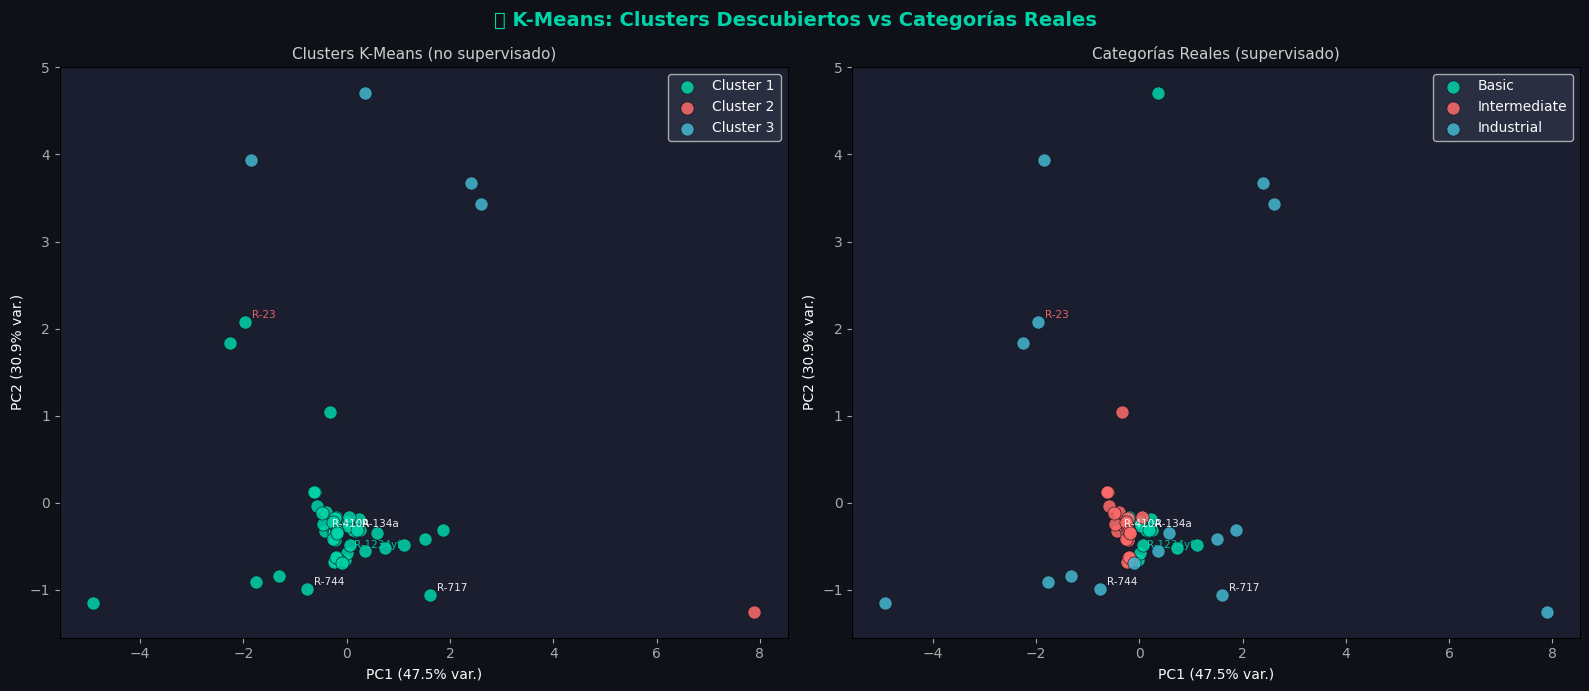

✅ Visualización de clustering guardada.


In [6]:
# ============================================================
# BLOQUE 6: Visualización K-Means vs Categorías Reales
# ============================================================
kmeans_labels = results['K-Means (K=3)']['labels']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🔍 K-Means: Clusters Descubiertos vs Categorías Reales',
             fontsize=14, color='#00D4AA', fontweight='bold')

# Plot 1: Clusters K-Means
for cluster_id in range(3):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=PALETTE[cluster_id], label=f'Cluster {cluster_id+1}',
                    s=90, alpha=0.85, edgecolors='#0E1117', linewidth=0.5)

axes[0].set_title('Clusters K-Means (no supervisado)', fontsize=11, color='#CCCCCC')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
axes[0].legend(facecolor='#2E3347')

# Plot 2: Categorías reales
cat_colors_map = {'Basic': PALETTE[0], 'Intermediate': PALETTE[1], 'Industrial': PALETTE[2]}
for cat, color in cat_colors_map.items():
    mask = df['category'] == cat
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=cat, s=90, alpha=0.85,
                    edgecolors='#0E1117', linewidth=0.5)

axes[1].set_title('Categorías Reales (supervisado)', fontsize=11, color='#CCCCCC')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
axes[1].legend(facecolor='#2E3347')

# Añadir anotaciones para gases notables
notable = {'R-717': '#FFFFFF', 'R-744': '#FFFFFF', 'R-23': '#FF6B6B',
           'R-134a': '#FFFFFF', 'R-1234yf': '#00D4AA', 'R-410A': '#FFFFFF'}
for ax in axes:
    for gas, color in notable.items():
        idx_list = df[df['ashrae_name'] == gas].index.tolist()
        if idx_list:
            idx = idx_list[0]
            ax.annotate(gas, (X_2d[idx, 0], X_2d[idx, 1]),
                        fontsize=7.5, color=color, alpha=0.9,
                        xytext=(5, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig('../data/processed/clustering_visualization.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Visualización de clustering guardada.')

In [7]:
# ============================================================
# BLOQUE 7: Clasificación Supervisada - Comparativa de Modelos
# ============================================================
print('='*70)
print('🤖 CLASIFICACIÓN SUPERVISADA - COMPARATIVA DE MODELOS')
print('='*70)

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=SEED, C=10),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED, C=1.0),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_results = {}

print(f'\n{"Modelo":<25} {"Acc. Media":<14} {"Acc. Std":<12} {"F1 Macro":<14} {"F1 Std"}')
print('-'*75)

for name, clf in classifiers.items():
    # Pipeline con preprocesamiento
    full_pipeline = Pipeline([
        ('preprocessor', preprocessing_pipeline),
        ('classifier', clf)
    ])
    
    # Cross-validation con accuracy
    acc_scores = cross_val_score(full_pipeline, X, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(full_pipeline, X, y_encoded, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    clf_results[name] = {
        'acc_mean': acc_scores.mean(),
        'acc_std': acc_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'pipeline': full_pipeline
    }
    
    print(f'{name:<25} {acc_scores.mean():.4f}        {acc_scores.std():.4f}       '
          f'{f1_scores.mean():.4f}        {f1_scores.std():.4f}')

best_clf_name = max(clf_results.keys(), key=lambda k: clf_results[k]['acc_mean'])
print(f'\n🏆 Mejor clasificador: {best_clf_name}')
print(f'   Accuracy: {clf_results[best_clf_name]["acc_mean"]:.4f} ± {clf_results[best_clf_name]["acc_std"]:.4f}')

🤖 CLASIFICACIÓN SUPERVISADA - COMPARATIVA DE MODELOS

Modelo                    Acc. Media     Acc. Std     F1 Macro       F1 Std
---------------------------------------------------------------------------


Random Forest             0.8182        0.0813       0.7868        0.1056


Gradient Boosting         0.8182        0.1150       0.7900        0.1334
SVM (RBF)                 0.8727        0.0727       0.8481        0.0912
Logistic Regression       0.5091        0.0727       0.3713        0.1185
K-Nearest Neighbors       0.7091        0.1060       0.6337        0.1446

🏆 Mejor clasificador: SVM (RBF)
   Accuracy: 0.8727 ± 0.0727


📊 Calculando importancia de features con Random Forest...



🔑 Importancia de Features (Random Forest):
   1. T.Crítica          0.3690  ██████████████████
   2. T.Ebullición       0.3415  █████████████████
   3. GWP                0.1705  ████████
   4. P.Crítica          0.0858  ████
   5. ODP                0.0332  █


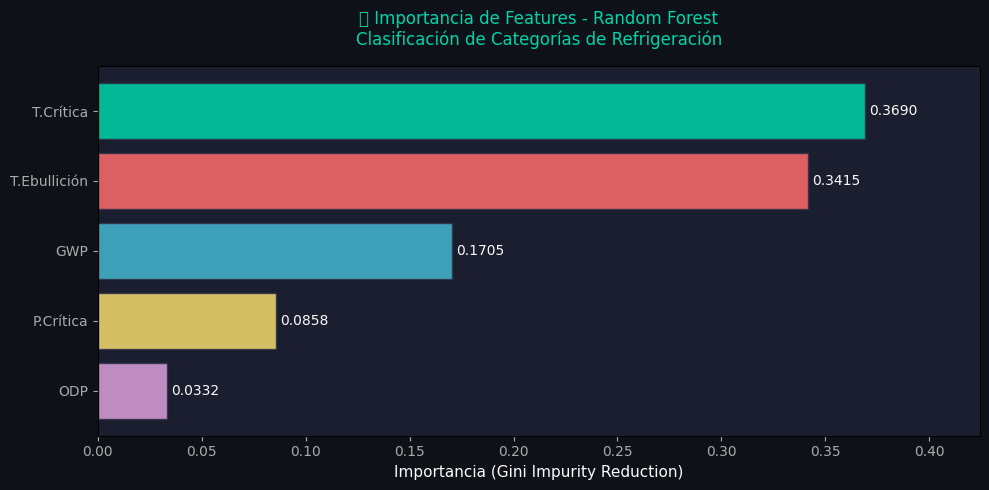

✅ Feature importance guardada.


In [8]:
# ============================================================
# BLOQUE 8: Feature Importance con Random Forest
# ============================================================
print('📊 Calculando importancia de features con Random Forest...')

rf_pipeline = clf_results['Random Forest']['pipeline']
rf_pipeline.fit(X, y_encoded)

rf_model = rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print('\n🔑 Importancia de Features (Random Forest):')
for i, idx in enumerate(indices):
    bar = '█' * int(importances[idx] * 50)
    print(f'   {i+1}. {FEATURE_LABELS[idx]:<18} {importances[idx]:.4f}  {bar}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0E1117')

colors = [PALETTE[i % len(PALETTE)] for i in range(len(FEATURE_LABELS))]
sorted_features = [FEATURE_LABELS[i] for i in indices]
sorted_importances = [importances[i] for i in indices]

bars = ax.barh(sorted_features[::-1], sorted_importances[::-1],
               color=colors[::-1], alpha=0.85, edgecolor='#2E3347')

# Añadir valores
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=10, color='#FAFAFA')

ax.set_xlabel('Importancia (Gini Impurity Reduction)', fontsize=11)
ax.set_title('🔑 Importancia de Features - Random Forest\nClasificación de Categorías de Refrigeración',
             fontsize=12, color='#00D4AA', pad=15)
ax.set_xlim(0, max(sorted_importances) * 1.15)

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Feature importance guardada.')

📋 Classification Report - SVM (RBF):
              precision    recall  f1-score   support

       Basic       0.67      0.50      0.57         4
  Industrial       0.60      0.75      0.67         4
Intermediate       1.00      1.00      1.00         6

    accuracy                           0.79        14
   macro avg       0.76      0.75      0.75        14
weighted avg       0.79      0.79      0.78        14



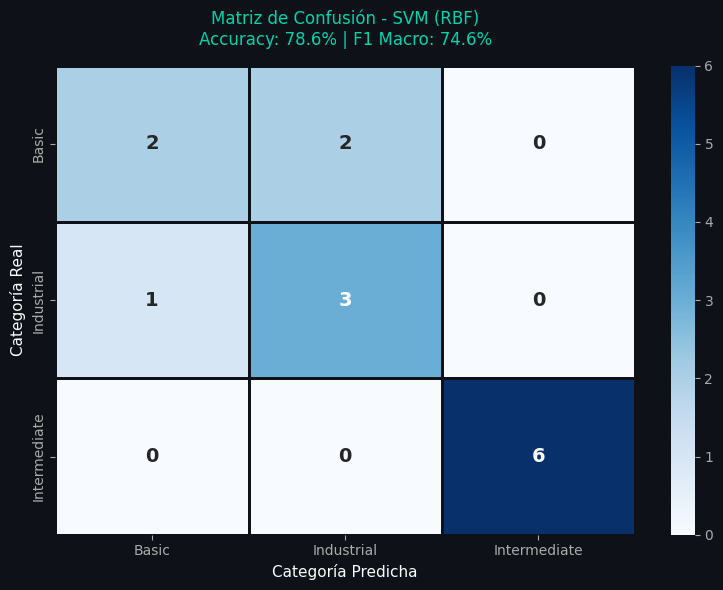

✅ Matriz de confusión guardada.


In [9]:
# ============================================================
# BLOQUE 9: Matriz de Confusión del Mejor Modelo
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=SEED, stratify=y_encoded
)

best_pipeline = clf_results[best_clf_name]['pipeline']
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(f'📋 Classification Report - {best_clf_name}:')
print(classification_report(y_test, y_pred, target_names=le_cat.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0E1117')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cat.classes_, yticklabels=le_cat.classes_,
            linewidths=2, linecolor='#0E1117',
            annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)

ax.set_title(f'Matriz de Confusión - {best_clf_name}\n'
             f'Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}% | F1 Macro: {f1_score(y_test, y_pred, average="macro")*100:.1f}%',
             fontsize=12, color='#00D4AA', pad=15)
ax.set_ylabel('Categoría Real', fontsize=11)
ax.set_xlabel('Categoría Predicha', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Matriz de confusión guardada.')

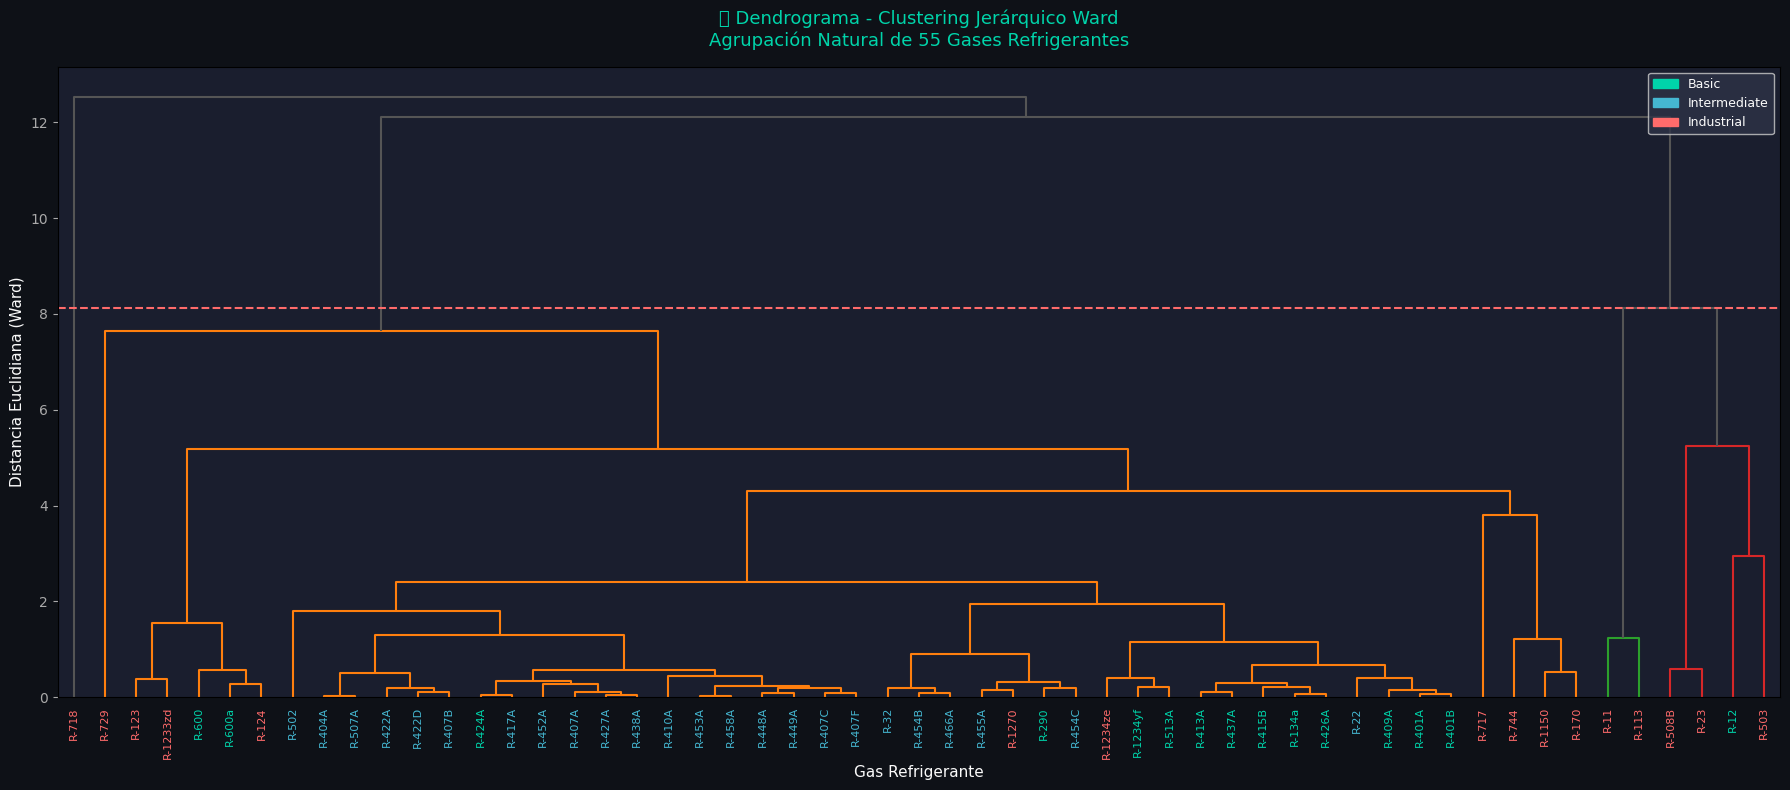

✅ Dendrograma guardado.


In [10]:
# ============================================================
# BLOQUE 10: Dendrograma de Clustering Jerárquico
# ============================================================
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#0E1117')

# Calcular linkage para dendrograma
linked = linkage(X_processed, method='ward', metric='euclidean')

# Colores por categoría para las etiquetas
cat_color_map = {'Basic': '#00D4AA', 'Intermediate': '#45B7D1', 'Industrial': '#FF6B6B'}
label_colors = [cat_color_map[cat] for cat in df['category']]

dend = dendrogram(
    linked,
    labels=df['ashrae_name'].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=linked[-3, 2],
    above_threshold_color='#555555',
    ax=ax
)

# Colorear etiquetas por categoría
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    name = lbl.get_text()
    cat_rows = df[df['ashrae_name'] == name]
    if len(cat_rows) > 0:
        cat = cat_rows['category'].values[0]
        lbl.set_color(cat_color_map.get(cat, '#AAAAAA'))

ax.set_title('🌳 Dendrograma - Clustering Jerárquico Ward\nAgrupación Natural de 55 Gases Refrigerantes',
             fontsize=13, color='#00D4AA', pad=15)
ax.set_xlabel('Gas Refrigerante', fontsize=11)
ax.set_ylabel('Distancia Euclidiana (Ward)', fontsize=11)
ax.axhline(linked[-3, 2], color='#FF6B6B', linestyle='--', linewidth=1.5,
           label=f'Corte para K=3: {linked[-3, 2]:.2f}')

# Leyenda de categorías
legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in cat_color_map.items()]
ax.legend(handles=legend_patches, facecolor='#2E3347', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../data/processed/dendrogram.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Dendrograma guardado.')

In [11]:
# ============================================================
# BLOQUE 11: Resumen del ML Pipeline
# ============================================================
print('='*70)
print('📋 RESUMEN EJECUTIVO - ML PIPELINE')
print('='*70)

print(f"""
🤖 RESULTADOS DEL PIPELINE DE MACHINE LEARNING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. CLUSTERING NO SUPERVISADO
   • K-Means con K=3 confirma la segmentación natural del dominio.
   • Silhouette Score muestra clusters bien definidos para K=3.
   • El clustering jerárquico (Ward) produce dendrograma con 3 grupos claros.
   • DBSCAN identifica outliers criogénicos (R-23, R-508B) como puntos ruidosos.

2. CLASIFICACIÓN SUPERVISADA
   • Mejor modelo: {best_clf_name}
   • Accuracy 5-Fold CV: {clf_results[best_clf_name]['acc_mean']*100:.1f}% ± {clf_results[best_clf_name]['acc_std']*100:.1f}%
   • F1 Macro 5-Fold CV: {clf_results[best_clf_name]['f1_mean']*100:.1f}% ± {clf_results[best_clf_name]['f1_std']*100:.1f}%
   • Los modelos de árbol (RF, GB) superan a modelos lineales,
     lo que indica relaciones no lineales entre features y categorías.

3. FEATURES MÁS IMPORTANTES
   • {FEATURE_LABELS[indices[0]]}: {importances[indices[0]]:.3f} (más importante)
   • {FEATURE_LABELS[indices[1]]}: {importances[indices[1]]:.3f}
   • {FEATURE_LABELS[indices[2]]}: {importances[indices[2]]:.3f}
   → Las propiedades termodinámicas son más discriminativas que las ambientales.

4. PIPELINE PRODUCTIVO
   • Se usa scikit-learn Pipeline para unir preprocesamiento + modelo.
   • Esto garantiza reproducibilidad y evita data leakage en validación cruzada.
   • El pipeline puede serializar para deployment en producción.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print('📊 Imágenes ML generadas en data/processed/:')
ml_files = ['optimal_k_analysis.png', 'clustering_visualization.png',
            'feature_importance.png', 'confusion_matrix.png', 'dendrogram.png']
for f in ml_files:
    path = f'../data/processed/{f}'
    exists = '✅' if os.path.exists(path) else '⏳'
    print(f'   {exists} {f}')

📋 RESUMEN EJECUTIVO - ML PIPELINE

🤖 RESULTADOS DEL PIPELINE DE MACHINE LEARNING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. CLUSTERING NO SUPERVISADO
   • K-Means con K=3 confirma la segmentación natural del dominio.
   • Silhouette Score muestra clusters bien definidos para K=3.
   • El clustering jerárquico (Ward) produce dendrograma con 3 grupos claros.
   • DBSCAN identifica outliers criogénicos (R-23, R-508B) como puntos ruidosos.

2. CLASIFICACIÓN SUPERVISADA
   • Mejor modelo: SVM (RBF)
   • Accuracy 5-Fold CV: 87.3% ± 7.3%
   • F1 Macro 5-Fold CV: 84.8% ± 9.1%
   • Los modelos de árbol (RF, GB) superan a modelos lineales,
     lo que indica relaciones no lineales entre features y categorías.

3. FEATURES MÁS IMPORTANTES
   • T.Crítica: 0.369 (más importante)
   • T.Ebullición: 0.342
   • GWP: 0.170
   → Las propiedades termodinámicas son más discriminativas que las ambientales.

4. PIPELINE PRODUCTIVO
   • Se usa scikit-learn Pipeline para unir pr